<a href="https://colab.research.google.com/github/gulcansercekus-svg/Regresyon-analizi/blob/main/Real_Estate_And_Housing_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbs

In [3]:
dataframe=pd.read_csv("Housing.csv")

In [4]:
dataframe.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
dataframe.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


<Figure size 1000x1000 with 0 Axes>

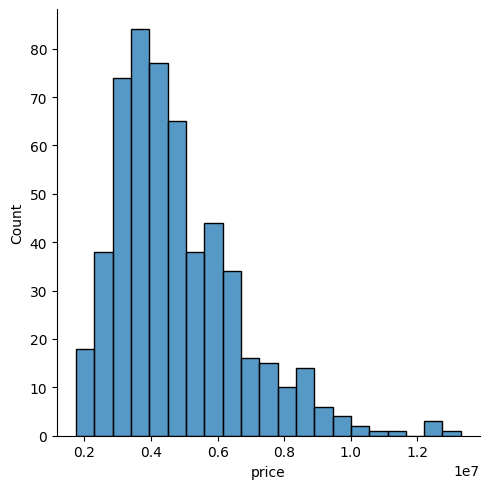

In [6]:
plt.figure(figsize=(10,10))
sbs.displot(dataframe["price"])

In [9]:
len(dataframe)*0.01

5.45

In [10]:
yuzdeDoksanDokuzDf=dataframe.sort_values("price",ascending=False).iloc[10:]
yuzdeDoksanDokuzDf.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.350000e+02,535.000000,535.000000,535.000000,535.000000,535.000000
mean,4.646023e+06,5069.542056,2.949533,1.269159,1.794393,0.669159
std,1.656135e+06,2071.808274,0.731370,0.472544,0.862649,0.844060
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3555.000000,2.000000,1.000000,1.000000,0.000000
50%,4.305000e+06,4500.000000,3.000000,1.000000,2.000000,0.000000
75%,5.600000e+06,6323.000000,3.000000,2.000000,2.000000,1.000000
max,9.800000e+06,15600.000000,6.000000,3.000000,4.000000,3.000000


In [11]:
dataframe=yuzdeDoksanDokuzDf

In [20]:
dataframe = pd.get_dummies(dataframe, drop_first=True)
y=dataframe["price"].values
x=dataframe.drop("price",axis=1).values

In [13]:
from sklearn.model_selection import train_test_split

In [21]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.3,random_state=10)

In [22]:
len(x_train)

374

In [23]:
from sklearn.preprocessing import MinMaxScaler

In [24]:
scaler=MinMaxScaler()

In [87]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [88]:
y_train_log=np.log1p(y_train)
y_test_log=np.log1p(y_test)

In [89]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [90]:
model=Sequential()

model.add(Dense(16, activation="relu")),Dropout(0.2)
model.add(Dense(8, activation="relu"))

model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

In [91]:
from tensorflow.keras.callbacks import EarlyStopping

In [92]:
earlyStopping= EarlyStopping(monitor="val_loss", mode="min",patience=25)

In [93]:
model.fit(x=x_train,y=y_train_log, validation_data=(x_test,y_test_log),batch_size=32,epochs=300, callbacks=[earlyStopping])

Epoch 1/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 226.8756 - val_loss: 222.8857
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 222.3782 - val_loss: 218.3039
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 217.7076 - val_loss: 213.3529
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 212.6103 - val_loss: 207.6555
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 206.6860 - val_loss: 201.0193
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 199.7081 - val_loss: 193.1180
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 191.1489 - val_loss: 183.2454
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 180.2993 - val_loss: 170.9242
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 166.6593 - val_loss: 155.3716
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 149.5543 - val_loss: 136.2134
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 128.7432 - val_loss: 112.8323
Epoch 12/300
12

<Axes: >

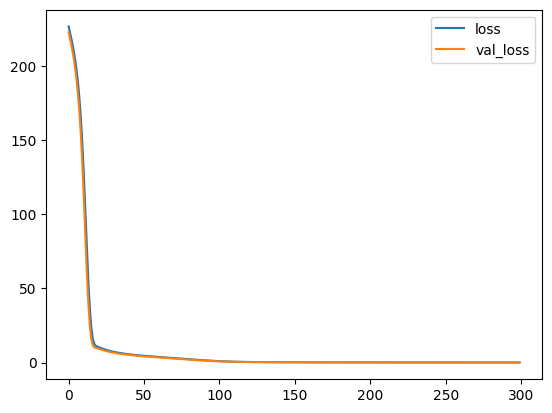

In [94]:
kayipveri=pd.DataFrame(model.history.history)
kayipveri.plot()


In [95]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [98]:
tahmin_log=model.predict(x_test)
tahmin_gercek=np.expm1(tahmin_log)
y_test_gercek=np.expm1(y_test_log)

mae=mean_absolute_error(y_test_gercek,tahmin_gercek)
r2=r2_score(y_test_gercek,tahmin_gercek)

print(f"Ortalama Mutlak Hata: {mae:,.2f}")
print(f"R2 Skoru (Açıklanan Varyans): {r2:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Ortalama Mutlak Hata: 790,726.36
R2 Skoru (Açıklanan Varyans): 0.5332
